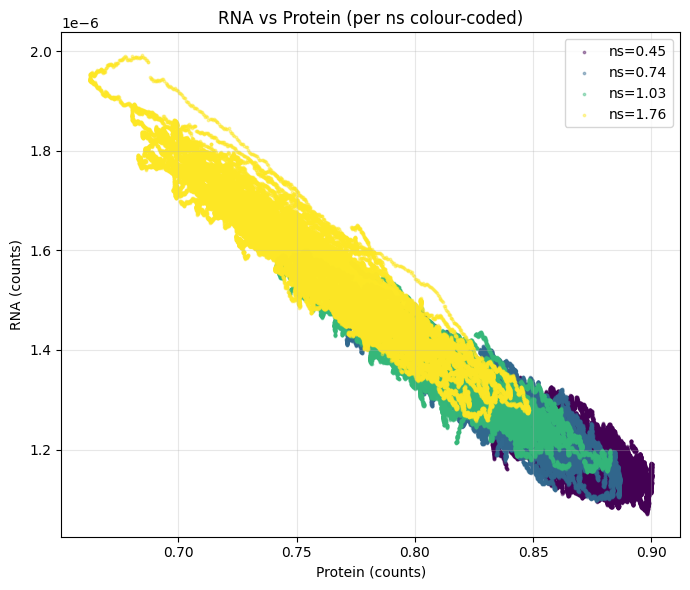

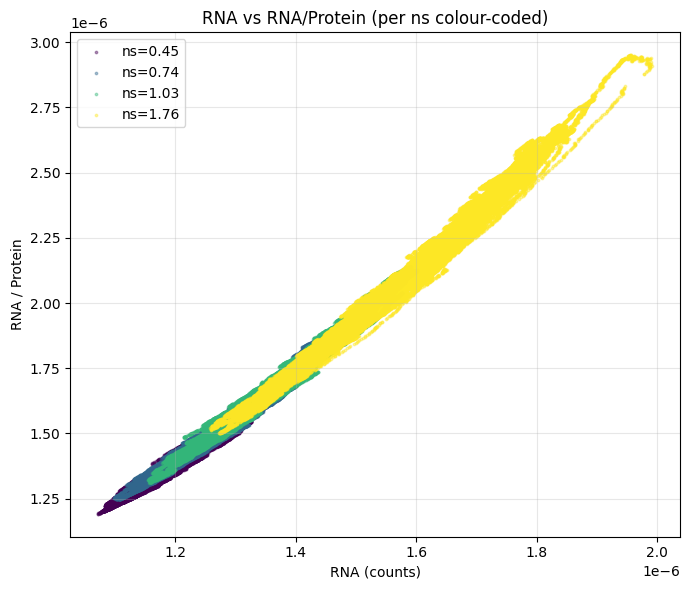

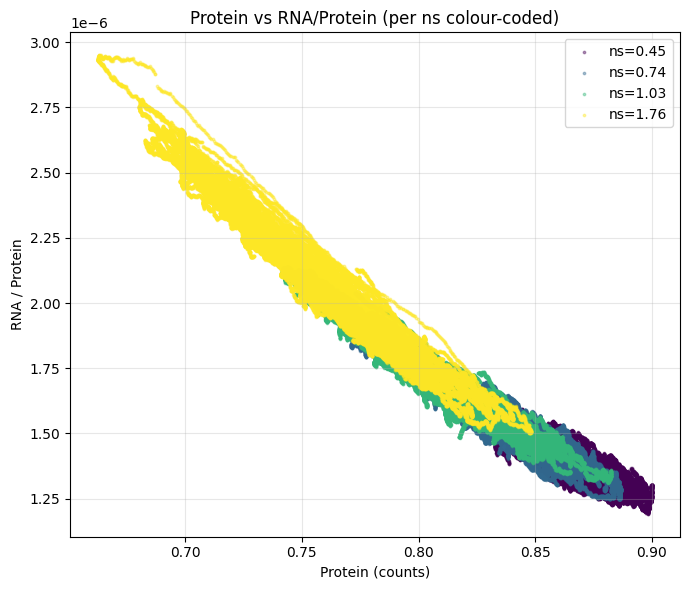

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0

# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# --------------------------------------------------------------
# Compute mass components
# --------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)

    total_mass = ribo_mass + prot_mass
    return total_mass, prot_mass

# --------------------------------------------------------------
# Compute RNA (free + bound)
# --------------------------------------------------------------
def compute_RNA(df):
    mm  = df["mm(t)"].to_numpy()
    mt  = df["mt(t)"].to_numpy()
    mq  = df["mq(t)"].to_numpy()
    mr  = df["mr(t)"].to_numpy()

    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    return mm + mt + mq + mr + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr


# --------------------------------------------------------------
# Collect per-ns data
# --------------------------------------------------------------
RNA_all = {}
PROT_all = {}
RATIO_all = {}

for ns, fn in FILES.items():
    df = load_arrow(fn)
    t = df["timestamp"].values
    mask = t >= BURN_IN
    df = df.loc[mask]

    RNA = compute_RNA(df)
    mass, prot_mass = compute_mass(df)

    RNA_m = RNA / mass
    PROT_m = prot_mass / mass
    RATIO = RNA_m / PROT_m

    RNA_all[ns]   = RNA_m
    PROT_all[ns]  = PROT_m
    RATIO_all[ns] = RATIO


# --------------------------------------------------------------
# Colours
# --------------------------------------------------------------
ns_list = list(FILES.keys())
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_list)))


# --------------------------------------------------------------
# Plot 1: RNA vs Protein
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(PROT_all[ns], RNA_all[ns], s=3, alpha=0.4, label=f"ns={ns}", color=col)

plt.xlabel("Protein (counts)")
plt.ylabel("RNA (counts)")
plt.title("RNA vs Protein (per ns colour-coded)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Plot 2: RNA vs RNA/Protein
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(RNA_all[ns], RATIO_all[ns], s=3, alpha=0.4, label=f"ns={ns}", color=col)

plt.xlabel("RNA (counts)")
plt.ylabel("RNA / Protein")
plt.title("RNA vs RNA/Protein (per ns colour-coded)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Plot 3: Protein vs RNA/Protein
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(PROT_all[ns], RATIO_all[ns], s=3, alpha=0.4, label=f"ns={ns}", color=col)

plt.xlabel("Protein (counts)")
plt.ylabel("RNA / Protein")
plt.title("Protein vs RNA/Protein (per ns colour-coded)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

# --------------------------------------------------------------
# Assuming these exist from your previous simulation code:
# RNA_m, PROT_m, RATIO = RNA/mass, Protein/mass, RNA/Protein
# --------------------------------------------------------------

data = {
    "RNA_mass": RNA_m,
    "Protein_mass": PROT_m,
    "RNA_Protein": RATIO
}

df_corr = pd.DataFrame(data)

# --------------------------------------------------------------
# Compute Pearson correlation and p-values
# --------------------------------------------------------------
variables = ["RNA_mass", "Protein_mass", "RNA_Protein"]

corr_matrix = pd.DataFrame(index=variables, columns=variables)
pval_matrix = pd.DataFrame(index=variables, columns=variables)

for v1 in variables:
    for v2 in variables:
        r, p = pearsonr(df_corr[v1], df_corr[v2])
        corr_matrix.loc[v1, v2] = r
        pval_matrix.loc[v1, v2] = p

# Convert to float type
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

print("=== Pearson Correlation Matrix ===")
print(corr_matrix)
print("\n=== p-value Matrix ===")
print(pval_matrix)

# --------------------------------------------------------------
# Also print pairwise correlations nicely
# --------------------------------------------------------------
print("\n=== Pairwise correlations ===")
for (v1, v2) in [("RNA_mass","Protein_mass"),
                 ("RNA_mass","RNA_Protein"),
                 ("Protein_mass","RNA_Protein")]:
    r, p = pearsonr(df_corr[v1], df_corr[v2])
    print(f"{v1} vs {v2}:  r = {r:.4f},   p = {p:.3e}")


=== Pearson Correlation Matrix ===
              RNA_mass  Protein_mass  RNA_Protein
RNA_mass      1.000000     -0.972264     0.996318
Protein_mass -0.972264      1.000000    -0.982521
RNA_Protein   0.996318     -0.982521     1.000000

=== p-value Matrix ===
              RNA_mass  Protein_mass  RNA_Protein
RNA_mass           0.0           0.0          0.0
Protein_mass       0.0           0.0          0.0
RNA_Protein        0.0           0.0          0.0

=== Pairwise correlations ===
RNA_mass vs Protein_mass:  r = -0.9723,   p = 0.000e+00
RNA_mass vs RNA_Protein:  r = 0.9963,   p = 0.000e+00
Protein_mass vs RNA_Protein:  r = -0.9825,   p = 0.000e+00


In [18]:
def lag1_autocorr(x):
    return np.corrcoef(x[:-1], x[1:])[0,1]
rho = lag1_autocorr(RNA_m_ds)
N = len(RNA_m_ds)
N_eff = N * ((1 - rho) / (1 + rho))
print("Effective N =", N_eff)
from scipy.stats import t

r = np.corrcoef(RNA_m_ds, PROT_m_ds)[0,1]
t_stat = r * np.sqrt((N_eff - 2) / (1 - r**2))
p_corrected = 2 * (1 - t.cdf(abs(t_stat), df=N_eff - 2))

print("Corrected p =", p_corrected)



Effective N = 66.16206287044682
Corrected p = 0.0


In [51]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
from scipy.stats import pearsonr, t

# ===============================================================
# FILES & CONSTANTS
# ===============================================================
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

BURN_IN = 1000.0  # minutes

# ===============================================================
# HELPERS
# ===============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def lag1_autocorr(x):
    """Compute lag-1 autocorrelation"""
    return np.corrcoef(x[:-1], x[1:])[0, 1]

def corrected_pvalue(x, y):
    """Pearson correlation + autocorrelation-corrected p-value"""
    r = np.corrcoef(x, y)[0,1]
    
    # effective sample size
    rho = lag1_autocorr(x)
    N = len(x)
    N_eff = N * (1 - rho) / (1 + rho)
    df = max(N_eff - 2, 1)

    # t-statistic
    t_stat = r * np.sqrt(df / (1 - r*r))
    p_val = 2 * (1 - t.cdf(abs(t_stat), df=df))

    return r, p_val, N_eff

# ===============================================================
# MAIN LOOP — compute absolute molecule correlations
# ===============================================================

for ns, filename in FILES.items():

    df = load_arrow(filename)
    time = df["timestamp"].to_numpy()
    mask = time >= BURN_IN


    # Absolute RNA counts
    RNA_total = (
        df["mm(t)"] + df["mt(t)"] +
        df["mq(t)"] + df["mr(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"]
    ).to_numpy()[mask]

    # Absolute protein counts
    Protein_total = (
        df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()[mask]

    # Ratio
    Ratio = RNA_total / Protein_total

    # Remove NaNs
    valid = (~np.isnan(RNA_total) &
             ~np.isnan(Protein_total) &
             ~np.isnan(Ratio))

    RNA_total = RNA_total[valid]
    Protein_total = Protein_total[valid]
    Ratio = Ratio[valid]

    # Compute correlations
    r1, p1, Neff1 = corrected_pvalue(RNA_total, Protein_total)
    r2, p2, Neff2 = corrected_pvalue(RNA_total, Ratio)
    r3, p3, Neff3 = corrected_pvalue(Protein_total, Ratio)

    print("\n========================================")
    print(f"   ns = {ns}")
    print("========================================")
    print(f"RNA vs Protein:         r = {r1:.4f}") #,  p = {p1:.10e}")
    print(f"RNA vs RNA/Protein:     r = {r2:.4f}") #,  p = {p2:.4e}")
    print(f"Protein vs RNA/Protein: r = {r3:.4f}") #,  p = {p3:.4e}")



   ns = 0.45
RNA vs Protein:         r = 0.9776
RNA vs RNA/Protein:     r = 0.3373
Protein vs RNA/Protein: r = 0.1366

   ns = 0.74
RNA vs Protein:         r = 0.9573
RNA vs RNA/Protein:     r = 0.5183
Protein vs RNA/Protein: r = 0.2575

   ns = 1.03
RNA vs Protein:         r = 0.9455
RNA vs RNA/Protein:     r = 0.5877
Protein vs RNA/Protein: r = 0.3031

   ns = 1.76
RNA vs Protein:         r = 0.9236
RNA vs RNA/Protein:     r = 0.6543
Protein vs RNA/Protein: r = 0.3281


In [29]:
import pandas as pd

# Load the new Scott growth-rate dataset
growth_df = pd.read_csv("Scott_data_growth.csv")

# Filter to drug-free condition (Dose = 0)
growth0 = growth_df[growth_df["Dose"] == 0].copy()

# Map Scott conditions to your 4 ns values
condition_to_ns = {
    "glu":     0.45,
    "caa_glu": 0.74,
    "gly":     1.03,
    "caa_gly": 1.76
}

growth0["ns"] = growth0["Condition"].map(condition_to_ns)

# Growth rate in 1/hour (Value column already in 1/h)
growth0["lambda_1h"] = growth0["Value"]

print(growth0)


   Condition  Dose     Value    ns  lambda_1h
0        glu     0  0.613329  0.45   0.613329
5    caa_glu     0  0.962800  0.74   0.962800
10       gly     0  0.439729  1.03   0.439729
15   caa_gly     0  0.740254  1.76   0.740254


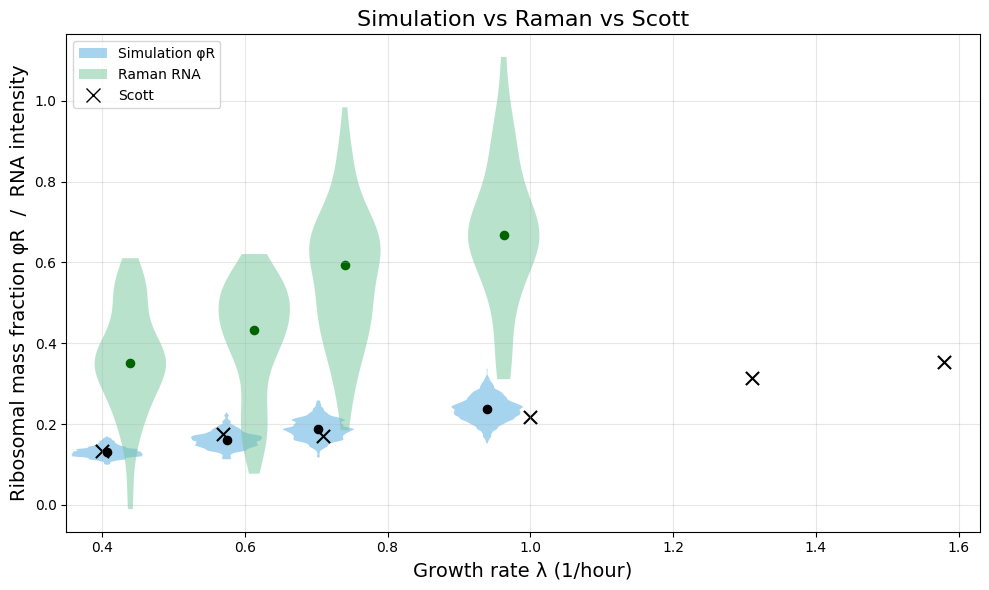

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# 1. Simulation Files + Constants
# ===============================================================
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes


# ===============================================================
# Helper functions
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR*(r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    non_ribo  = NX*(q+et+em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma


# ===============================================================
# 2. LOAD SIMULATION DATA
# ===============================================================
sim_lambda_mean = []
phiR_sim_all = []

for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]

    ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    lam = (ttrate / mass_full) * 60.0   # 1/hour
    phiR = ribo_mass / mass_full

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    lam = lam[valid]
    phiR = phiR[valid]

    sim_lambda_mean.append(np.mean(lam))
    phiR_sim_all.append(phiR)

sim_lambda_mean = np.array(sim_lambda_mean)


# ===============================================================
# 3. LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott0 = scott[scott["cl"] == 0]

lambda_scott = scott0["lambda"].values * 60     # already 1/hour
phiR_scott   = scott0["fr"].values


# ===============================================================
# 4. LOAD RAMAN DATA (full distributions)
# ===============================================================
rna = pd.read_csv("Data/rna.csv")

# Extract **RNA intensities**, not ratios**
raman_intensities = [
    rna["Cm0_gly"].dropna().to_numpy(),        # glycerol
    rna["Cm0_glu"].dropna().to_numpy(),        # glucose
    rna["Cm0_caa_gly"].dropna().to_numpy(),    # glycerol + CAA
    rna["Cm0_caa_glu"].dropna().to_numpy(),    # glucose + CAA
]
# raman_intensities = [
#     (rna[col].dropna() - rna[col].dropna().mean()) / rna[col].dropna().std()
#     for col in ["Cm0_gly","Cm0_glu","Cm0_caa_gly","Cm0_caa_glu"]
# ]
RNA_SCALE = 1000
raman_intensities = [vals / RNA_SCALE for vals in raman_intensities]

# Raman growth rates in correct order
raman_lambda = np.array([
    0.439728801,  # Glycerol
    0.613329148,  # Glucose
    0.740254289,  # Glycerol+CAA
    0.962799856   # Glucose+CAA
])


# ===============================================================
# 6. PLOT: Simulation violins + Raman violins + Scott points
# ===============================================================
plt.figure(figsize=(10,6))

# -------------------------------
# SIMULATION VIOLINS (blue)
# -------------------------------
parts_sim = plt.violinplot(
    phiR_sim_all,
    positions=sim_lambda_mean,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_sim['bodies']:
    pc.set_facecolor("#4ea8de")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(sim_lambda_mean, phiR_sim_all):
    plt.scatter(lam, np.median(dist), s=35, color="black")

# -------------------------------
# RAMAN VIOLINS (green)
# -------------------------------
parts_ram = plt.violinplot(
    raman_intensities,
    positions=raman_lambda,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_ram['bodies']:
    pc.set_facecolor("#74c69d")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(raman_lambda, raman_intensities):
    plt.scatter(lam, np.median(dist), s=35, color="darkgreen")


# -------------------------------
# SCOTT POINTS (black X)
# -------------------------------
plt.scatter(lambda_scott, phiR_scott,
            color='black', marker='x', s=90, label="Scott")


# -------------------------------
# AXES & LABELS
# -------------------------------
plt.xlabel("Growth rate λ (1/hour)", fontsize=14)
plt.ylabel("Ribosomal mass fraction φR  /  RNA intensity", fontsize=14)
plt.title("Simulation vs Raman vs Scott", fontsize=16)

plt.grid(alpha=0.3)

# Expand x-range slightly for clarity
xmin = min(sim_lambda_mean.min(), raman_lambda.min(), lambda_scott.min()) - 0.05
xmax = max(sim_lambda_mean.max(), raman_lambda.max(), lambda_scott.max()) + 0.05
plt.xlim(xmin, xmax)

# -------------------------------
# LEGEND
# -------------------------------
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#4ea8de", alpha=0.5, label='Simulation φR'),
    Patch(facecolor="#74c69d", alpha=0.5, label='Raman RNA'),
    Line2D([0], [0], marker='x', color='black', linestyle='None',
           markersize=10, label='Scott')
]

plt.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.show()


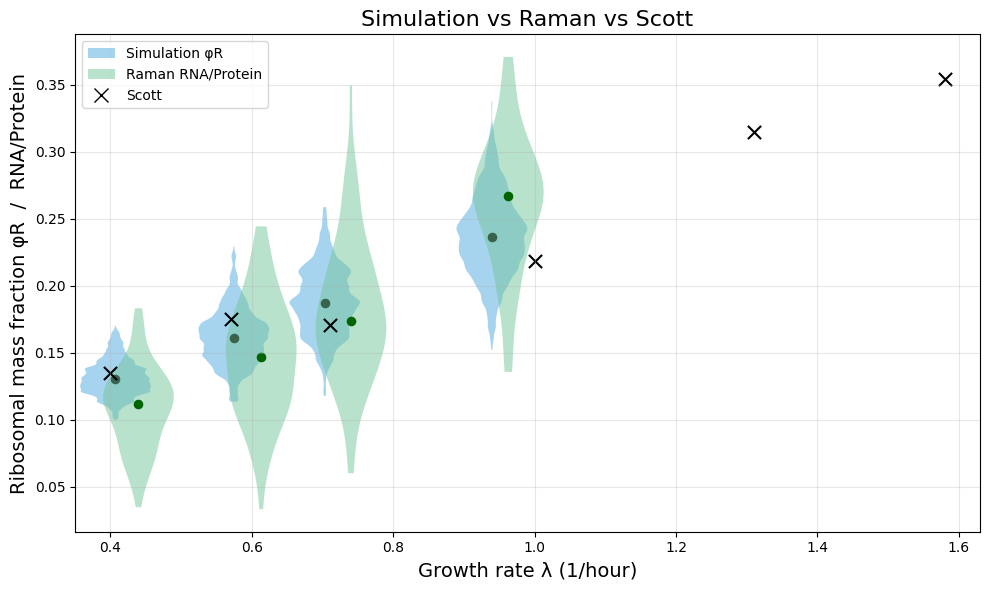

Simulation λ means: [0.40724329 0.57452815 0.70320157 0.93953208]
Raman λ: [0.4397288  0.61332915 0.74025429 0.96279986]
Rmf: [array([0.12129986, 0.12124539, 0.12122454, ..., 0.12419681, 0.12419681,
       0.12419681], shape=(305226,)), array([0.16874599, 0.1687731 , 0.16879076, ..., 0.16623824, 0.16623824,
       0.16623824], shape=(215594,)), array([0.19544515, 0.19560215, 0.19572619, ..., 0.15362509, 0.15362509,
       0.15362509], shape=(175813,)), array([0.21501516, 0.2149679 , 0.21492663, ..., 0.28623425, 0.28623425,
       0.28623425], shape=(131556,))]


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# 1. Simulation Files + Constants
# ===============================================================
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes


# ===============================================================
# Helper functions
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR*(r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    non_ribo  = NX*(q+et+em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma


# ===============================================================
# 2. LOAD SIMULATION DATA
# ===============================================================
sim_lambda_mean = []
phiR_sim_all = []

for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]

    ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    lam = (ttrate / mass_full) * 60.0   # 1/hour
    phiR = ribo_mass / mass_full

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    lam = lam[valid]
    phiR = phiR[valid]

    sim_lambda_mean.append(np.mean(lam))
    phiR_sim_all.append(phiR)

sim_lambda_mean = np.array(sim_lambda_mean)


# ===============================================================
# 3. LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott0 = scott[scott["cl"] == 0]

lambda_scott = scott0["lambda"].values * 60     # already 1/hour
phiR_scott   = scott0["fr"].values


# ===============================================================
# 4. LOAD RAMAN DATA (full distributions)
# ===============================================================
# Means & SDs for *Cm0* (no antibiotic) samples
raman_ratio_means = np.array([0.3133, 0.4043, 0.5151, 0.7307])
raman_sds         = np.array([0.09259, 0.1189, 0.1455, 0.1466])

# reconstruct distributions (79 samples each)
raman_distributions = [
    np.random.normal(mu, sd, size=79)
    for mu, sd in zip(raman_ratio_means, raman_sds)
]
RAMAN_SCALE = 0.35   
raman_distributions = [dist * RAMAN_SCALE for dist in raman_distributions]

# Raman growth rates in correct order
raman_lambda = np.array([
    0.439728801,  # Glycerol
    0.613329148,  # Glucose
    0.740254289,  # Glycerol+CAA
    0.962799856   # Glucose+CAA
])


# ===============================================================
# 6. PLOT: Simulation violins + Raman violins + Scott points
# ===============================================================
plt.figure(figsize=(10,6))

# -------------------------------
# SIMULATION VIOLINS (blue)
# -------------------------------
parts_sim = plt.violinplot(
    phiR_sim_all,
    positions=sim_lambda_mean,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_sim['bodies']:
    pc.set_facecolor("#4ea8de")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(sim_lambda_mean, phiR_sim_all):
    plt.scatter(lam, np.median(dist), s=35, color="black")

# -------------------------------
# RAMAN VIOLINS (green)
# -------------------------------
parts_ram = plt.violinplot(
    raman_distributions,
    positions=raman_lambda,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_ram['bodies']:
    pc.set_facecolor("#74c69d")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(raman_lambda, raman_distributions):
    plt.scatter(lam, np.median(dist), s=35, color="darkgreen")

# -------------------------------
# SCOTT POINTS (black X)
# -------------------------------
plt.scatter(lambda_scott, phiR_scott,
            color='black', marker='x', s=90, label="Scott")


# -------------------------------
# AXES & LABELS
# -------------------------------
plt.xlabel("Growth rate λ (1/hour)", fontsize=14)
plt.ylabel("Ribosomal mass fraction φR  /  RNA/Protein", fontsize=14)
plt.title("Simulation vs Raman vs Scott", fontsize=16)

plt.grid(alpha=0.3)

# Expand x-range slightly for clarity
xmin = min(sim_lambda_mean.min(), raman_lambda.min(), lambda_scott.min()) - 0.05
xmax = max(sim_lambda_mean.max(), raman_lambda.max(), lambda_scott.max()) + 0.05
plt.xlim(xmin, xmax)

# -------------------------------
# LEGEND
# -------------------------------
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#4ea8de", alpha=0.5, label='Simulation φR'),
    Patch(facecolor="#74c69d", alpha=0.5, label='Raman RNA/Protein'),
    Line2D([0], [0], marker='x', color='black', linestyle='None',
           markersize=10, label='Scott')
]

plt.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.show()
print("Simulation λ means:", sim_lambda_mean)
print("Raman λ:", raman_lambda)
print("Rmf:", phiR_sim_all)



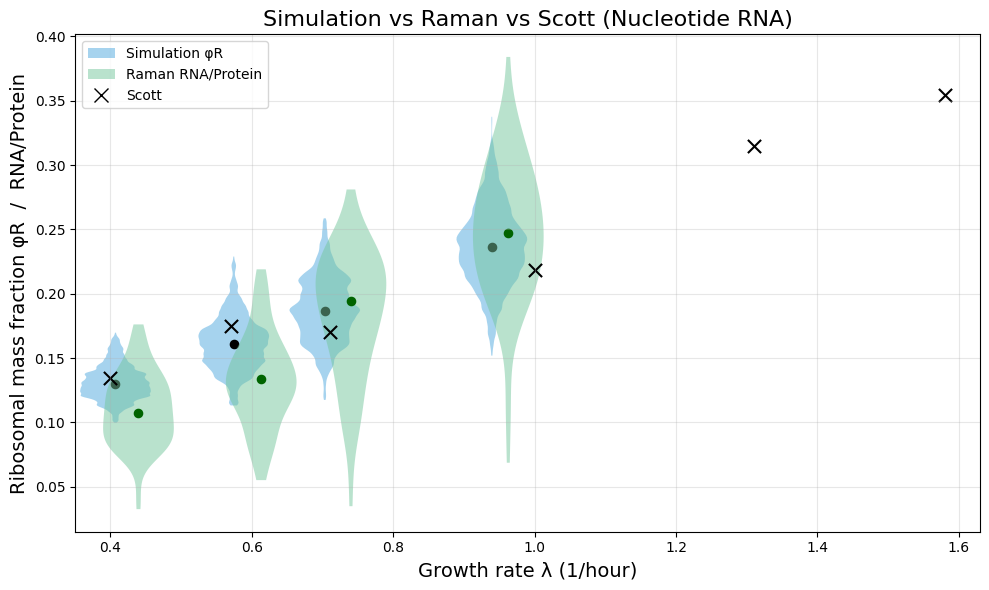

Simulation λ means: [0.40724329 0.57452815 0.70320157 0.93953208]
Raman λ: [0.4397288  0.61332915 0.74025429 0.96279986]
Rmf: [array([0.12129986, 0.12124539, 0.12122454, ..., 0.12419681, 0.12419681,
       0.12419681], shape=(305226,)), array([0.16874599, 0.1687731 , 0.16879076, ..., 0.16623824, 0.16623824,
       0.16623824], shape=(215594,)), array([0.19544515, 0.19560215, 0.19572619, ..., 0.15362509, 0.15362509,
       0.15362509], shape=(175813,)), array([0.21501516, 0.2149679 , 0.21492663, ..., 0.28623425, 0.28623425,
       0.28623425], shape=(131556,))]


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# 1. Simulation Files + Constants
# ===============================================================
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

MRNA_LENGTHS_AA = {
    "mm": NX,   # 300 AA
    "mt": NX,
    "mq": NX,
    "mr": NR    # 7549 AA
}

# Corrected rRNA length per ribosome
RIBO_RNA_NT = 4565


# ===============================================================
# Helper functions
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR*(r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    non_ribo  = NX*(q+et+em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    # Free + bound mRNAs
    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    # Free + bound ribosomes
    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    return mRNA_mass + rRNA_mass


# --------------------------------------------------------------
# NEW: Correct total mass for analysis
# --------------------------------------------------------------
def compute_total_mass_new(protein_mass, rna_mass_nt):
    return protein_mass #+ rna_mass_nt

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma


# ===============================================================
# 2. LOAD SIMULATION DATA
# ===============================================================
sim_lambda_mean = []
phiR_sim_all = []

for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]
    
    # Mass components
    ribo_prot_mass, protein_mass = compute_mass(df)
    RNA_nt = compute_RNA_nt(df, MRNA_LENGTHS_AA)

    total_mass_new = protein_mass #+ RNA_nt

    ttrate = compute_ttrate(df, total_mass_new)

    lam = (ttrate / total_mass_new) * 60.0
    phiR = ribo_prot_mass / total_mass_new


    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    lam = lam[valid]
    phiR = phiR[valid]

    sim_lambda_mean.append(np.mean(lam))
    phiR_sim_all.append(phiR)

sim_lambda_mean = np.array(sim_lambda_mean)


# ===============================================================
# 3. LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott0 = scott[scott["cl"] == 0]

lambda_scott = scott0["lambda"].values * 60     # already 1/hour
phiR_scott   = scott0["fr"].values


# ===============================================================
# 4. LOAD RAMAN DATA (full distributions)
# ===============================================================
# Means & SDs for *Cm0* (no antibiotic) samples
raman_ratio_means = np.array([0.3133, 0.4043, 0.5151, 0.7307])
raman_sds         = np.array([0.09259, 0.1189, 0.1455, 0.1466])

# reconstruct distributions (79 samples each)
raman_distributions = [
    np.random.normal(mu, sd, size=79)
    for mu, sd in zip(raman_ratio_means, raman_sds)
]
RAMAN_SCALE = 0.35 #0.4
raman_distributions = [dist * RAMAN_SCALE for dist in raman_distributions]

# Raman growth rates in correct order
raman_lambda = np.array([
    0.439728801,  # Glycerol
    0.613329148,  # Glucose
    0.740254289,  # Glycerol+CAA
    0.962799856   # Glucose+CAA
])


# ===============================================================
# 6. PLOT: Simulation violins + Raman violins + Scott points
# ===============================================================
plt.figure(figsize=(10,6))

# -------------------------------
# SIMULATION VIOLINS (blue)
# -------------------------------
parts_sim = plt.violinplot(
    phiR_sim_all,
    positions=sim_lambda_mean,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_sim['bodies']:
    pc.set_facecolor("#4ea8de")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(sim_lambda_mean, phiR_sim_all):
    plt.scatter(lam, np.median(dist), s=35, color="black")

# -------------------------------
# RAMAN VIOLINS (green)
# -------------------------------
parts_ram = plt.violinplot(
    raman_distributions,
    positions=raman_lambda,
    widths=0.10,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts_ram['bodies']:
    pc.set_facecolor("#74c69d")
    pc.set_alpha(0.50)

# medians
for lam, dist in zip(raman_lambda, raman_distributions):
    plt.scatter(lam, np.median(dist), s=35, color="darkgreen")

# -------------------------------
# SCOTT POINTS (black X)
# -------------------------------
plt.scatter(lambda_scott, phiR_scott,
            color='black', marker='x', s=90, label="Scott")


# -------------------------------
# AXES & LABELS
# -------------------------------
plt.xlabel("Growth rate λ (1/hour)", fontsize=14)
plt.ylabel("Ribosomal mass fraction φR  /  RNA/Protein", fontsize=14)
plt.title("Simulation vs Raman vs Scott (Nucleotide RNA)", fontsize=16)

plt.grid(alpha=0.3)

# Expand x-range slightly for clarity
xmin = min(sim_lambda_mean.min(), raman_lambda.min(), lambda_scott.min()) - 0.05
xmax = max(sim_lambda_mean.max(), raman_lambda.max(), lambda_scott.max()) + 0.05
plt.xlim(xmin, xmax)

# -------------------------------
# LEGEND
# -------------------------------
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#4ea8de", alpha=0.5, label='Simulation φR'),
    Patch(facecolor="#74c69d", alpha=0.5, label='Raman RNA/Protein'),
    Line2D([0], [0], marker='x', color='black', linestyle='None',
           markersize=10, label='Scott')
]

plt.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.show()

print("Simulation λ means:", sim_lambda_mean)
print("Raman λ:", raman_lambda)
print("Rmf:", phiR_sim_all)



Aligned datapoints: 1580

RNA vs Protein:
  Pearson  r = 0.7047,  p = 1.95e-237
  Spearman r = 0.7027,  p = 1.56e-235

RNA vs RNA/Protein:
  Pearson  r = -0.0149,  p = 5.54e-01
  Spearman r = 0.1261,  p = 4.94e-07

Protein vs RNA/Protein:
  Pearson  r = -0.4147,  p = 1.08e-66
  Spearman r = -0.5298,  p = 4.87e-115


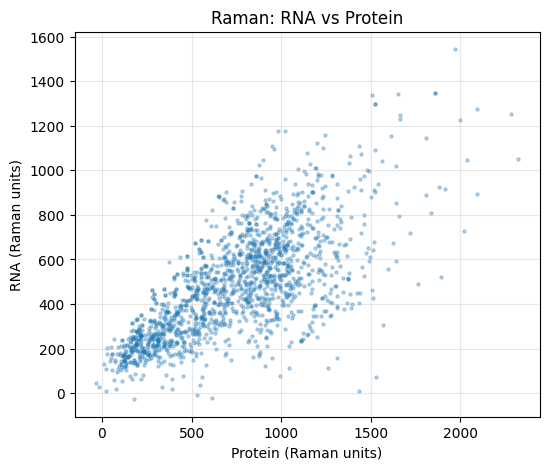

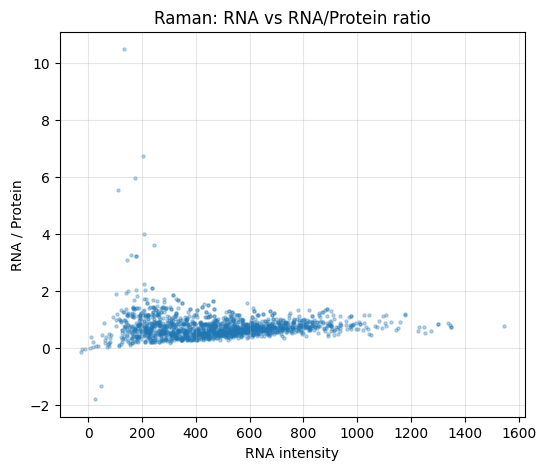

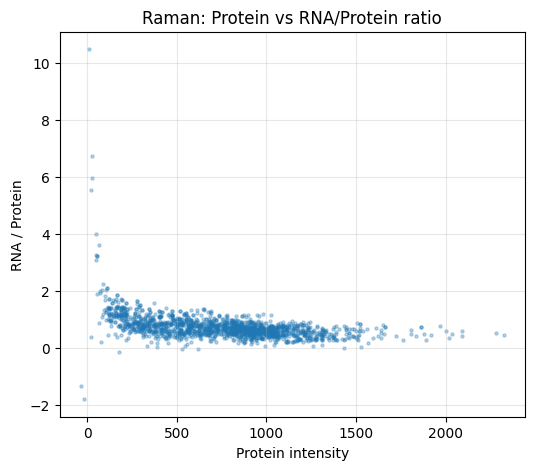

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

RNA = pd.read_csv("Data/rna.csv")
PROT = pd.read_csv("Data/protein.csv")
RATIO = pd.read_csv("Data/rna_protein.csv")

# Remove any fully empty rows or columns
RNA = RNA.dropna(how='all').dropna(axis=1, how='all')
PROT = PROT.dropna(how='all').dropna(axis=1, how='all')
RATIO = RATIO.dropna(how='all').dropna(axis=1, how='all')

def extract_block(df, start_col, end_col):
    block = df.iloc[:, start_col:end_col]
    block = block.apply(pd.to_numeric, errors='coerce')
    return block.values.flatten()

# Raman sheet column layout:
# 5 columns per dose block (Cm0–Cm12)
block_size = 5

# There are 4 media types, each with 5 doses
blocks = []
for media in range(4):
    col_start = media * block_size
    col_end   = col_start + block_size
    blocks.append((col_start, col_end))

rna_vals = []
prot_vals = []
ratio_vals = []

for (c0, c1) in blocks:
    rna_vals.append(extract_block(RNA, c0, c1))
    prot_vals.append(extract_block(PROT, c0, c1))
    ratio_vals.append(extract_block(RATIO, c0, c1))

rna_vals = np.concatenate(rna_vals)
prot_vals = np.concatenate(prot_vals)
ratio_vals = np.concatenate(ratio_vals)

# Clean NaNs
mask = (~np.isnan(rna_vals)) & (~np.isnan(prot_vals)) & (~np.isnan(ratio_vals))
rna_vals = rna_vals[mask]
prot_vals = prot_vals[mask]
ratio_vals = ratio_vals[mask]

print("Aligned datapoints:", len(rna_vals))

def corr(name_x, X, name_y, Y):
    rp, pp = pearsonr(X, Y)
    rs, ps = spearmanr(X, Y)
    print(f"\n{name_x} vs {name_y}:")
    print(f"  Pearson  r = {rp:.4f},  p = {pp:.2e}")
    print(f"  Spearman r = {rs:.4f},  p = {ps:.2e}")

corr("RNA", rna_vals, "Protein", prot_vals)
corr("RNA", rna_vals, "RNA/Protein", ratio_vals)
corr("Protein", prot_vals, "RNA/Protein", ratio_vals)

plt.figure(figsize=(6,5))
plt.scatter(prot_vals, rna_vals, s=5, alpha=0.3)
plt.xlabel("Protein (Raman units)")
plt.ylabel("RNA (Raman units)")
plt.title("Raman: RNA vs Protein")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(rna_vals, ratio_vals, s=5, alpha=0.3)
plt.xlabel("RNA intensity")
plt.ylabel("RNA / Protein")
plt.title("Raman: RNA vs RNA/Protein ratio")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(prot_vals, ratio_vals, s=5, alpha=0.3)
plt.xlabel("Protein intensity")
plt.ylabel("RNA / Protein")
plt.title("Raman: Protein vs RNA/Protein ratio")
plt.grid(alpha=0.3)
plt.show()
